In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-data/covid19 dataset/normal/Normal-859.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-158.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-10121.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-1811.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-97.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-1088.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-5663.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-6328.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-8410.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-5641.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-4852.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-9518.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-6443.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-6391.png
/kaggle/input/covid19-data/covid19 dataset/normal/Normal-8481.png
/kaggle/input

**DATA ANALYSIS**

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import pandas as pd


In [3]:
import os

base_dir = '/kaggle/input/covid19-data/covid19 dataset'

# Check actual folders
print("Folders found in dataset:")
print(os.listdir(base_dir))


Folders found in dataset:
['normal', 'covid19']


{'normal': 10192, 'covid19': 3616}


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


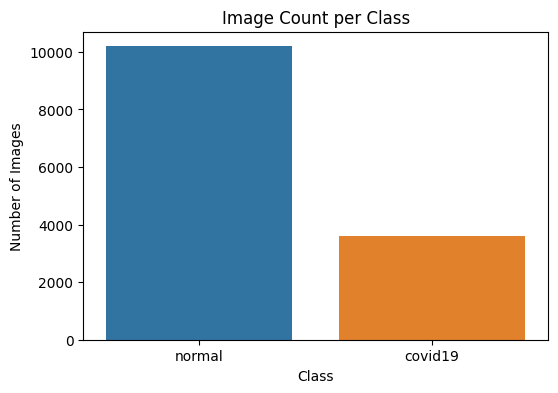

In [4]:
classes = os.listdir(base_dir)  # or manually: ['Covid', 'Normal']
# Count images per class
class_counts = {}
for cls in classes:
    class_path = os.path.join(base_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))
print(class_counts)
# Plotting class distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Image Count per Class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


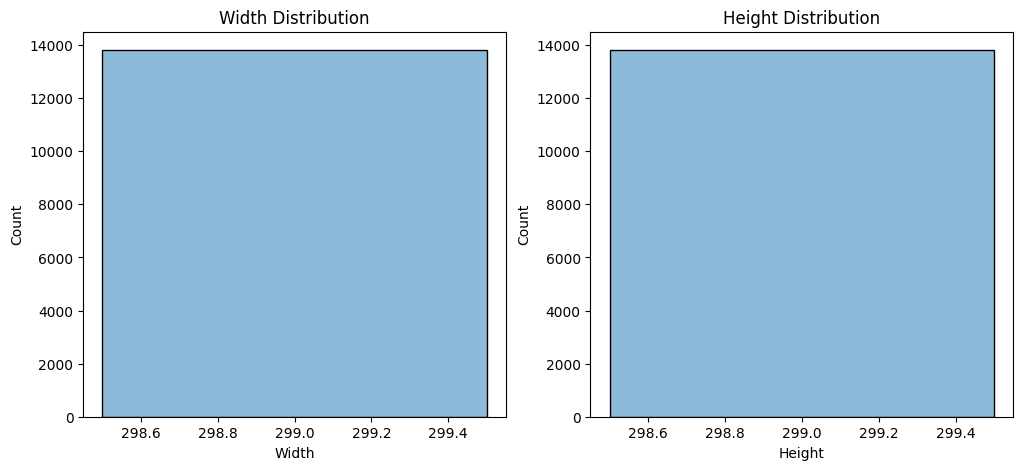

In [5]:
from collections import Counter

image_shapes = []

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            image_shapes.append(img.size)  # (width, height)
        except:
            continue  # Skip unreadable images

# Convert to DataFrame for analysis
df_shapes = pd.DataFrame(image_shapes, columns=['Width', 'Height'])

# Plot width & height distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_shapes['Width'], kde=True)
plt.title("Width Distribution")
plt.subplot(1, 2, 2)
sns.histplot(df_shapes['Height'], kde=True)
plt.title("Height Distribution")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


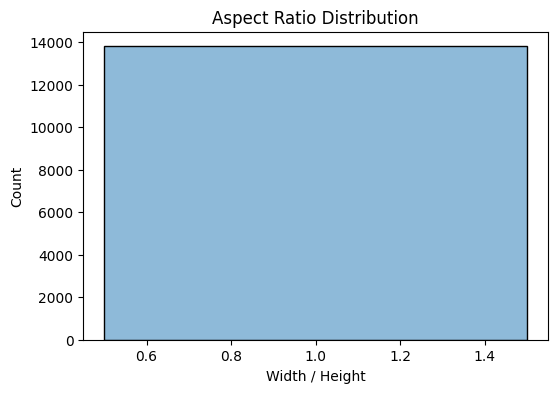

In [6]:

df_shapes['Aspect Ratio'] = df_shapes['Width'] / df_shapes['Height']

plt.figure(figsize=(6, 4))
sns.histplot(df_shapes['Aspect Ratio'], kde=True)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.show()


In [7]:

corrupted_images = []

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  # Verify if image can be read
        except:
            corrupted_images.append(img_path)

print(f"Found {len(corrupted_images)} corrupted images.")


Found 0 corrupted images.


**SIMPLE CNN**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


base_dir = '/kaggle/input/covid19-dataset/covid19 dataset'  

# Image settings
IMAGE_SIZE = (150,150)
BATCH_SIZE = 32
EPOCHS = 10


In [12]:
base_dir="/kaggle/input/covid19-data/covid19 dataset"
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)  # 30% for validation

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 9667 images belonging to 2 classes.
Found 4141 images belonging to 2 classes.


In [21]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


In [14]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [24]:
import time
start_time = time.time()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

# End timing
end_time = time.time()

# Print total time taken
execution_time = end_time - start_time
print(f"Training completed in {execution_time:.2f} seconds ({execution_time/60:.2f} minutes)")

Epoch 1/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - accuracy: 0.7982 - loss: 0.4137 - val_accuracy: 0.9123 - val_loss: 0.2240
Epoch 2/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - accuracy: 0.9201 - loss: 0.2083 - val_accuracy: 0.9237 - val_loss: 0.1942
Epoch 3/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.9392 - loss: 0.1521 - val_accuracy: 0.9425 - val_loss: 0.1610
Epoch 4/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - accuracy: 0.9587 - loss: 0.1157 - val_accuracy: 0.9457 - val_loss: 0.1594
Epoch 5/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.9644 - loss: 0.0983 - val_accuracy: 0.9324 - val_loss: 0.1936
Epoch 6/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 40s 134ms/step - accuracy: 0.9746 - loss: 0.0738 - val_accuracy: 0.9524 - val_loss: 0.1531
Epoch 7/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.9765 - loss: 0.0627 - val_accuracy: 0.9587 - val_loss: 0.1522
Epoch 8/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - accuracy: 0.9772 - loss: 0

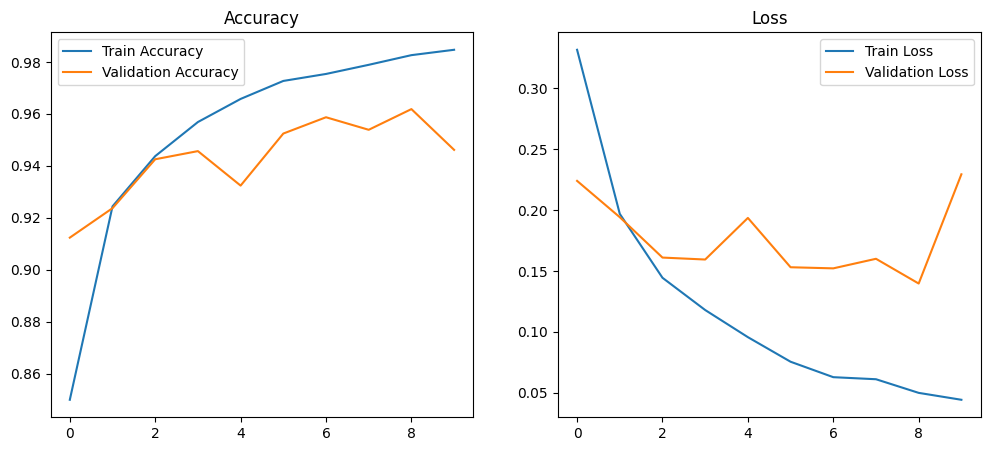

In [25]:

# Plot accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [26]:
# Evaluate with confusion matrix
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_preds = (y_pred_probs > 0.5).astype(int)


130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step


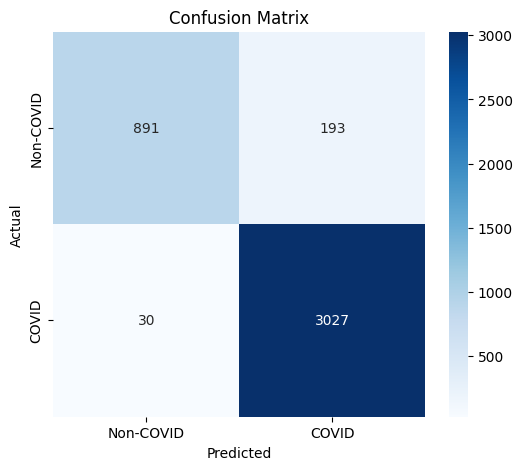

In [27]:
# Confusion matrix
cm = confusion_matrix(val_generator.classes, y_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-COVID', 'COVID'],
            yticklabels=['Non-COVID', 'COVID'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:

# Classification report
print(classification_report(val_generator.classes, y_preds, target_names=['Non-COVID', 'COVID']))


              precision    recall  f1-score   support

   Non-COVID       0.97      0.82      0.89      1084
       COVID       0.94      0.99      0.96      3057

    accuracy                           0.95      4141
   macro avg       0.95      0.91      0.93      4141
weighted avg       0.95      0.95      0.94      4141



In [34]:

# Save model
model.save('/kaggle/working/covid_simple_cnn.h5')